Импорты:

In [11]:
import time
import numpy as np
import matplotlib.pyplot as plt
from math import log, factorial

Фукнция:

In [12]:
def f(x):
    """Исходная функция f(x) = ln(x)"""
    return np.log(x)

Аппроксимация простыми:

In [13]:
def g_n(x, n):
    """Вспомогательная функция g_n(x)"""
    x = np.asarray(x)
    return np.floor(n * np.log(x)) / n

Последовательность монотонная:

In [14]:
def f_n(x, n):
    """Построение f_n(x) = max{g_1(x), g_2(x), ..., g_n(x)}"""
    x = np.asarray(x)
    values = np.stack([g_n(x, k) for k in range(1, n + 1)], axis=0)
    return np.max(values, axis=0)

Интеграл Лебега

In [15]:
def lebesgue_integral_numeric(n, num_points=200000):
    """Численное вычисление интеграла Лебега от f_n"""
    xs = np.linspace(1.0, 4.0, num_points)
    ys = f_n(xs, n)
    return np.trapezoid(ys, xs)

Интеграл Лебега–Стилтьеса

In [16]:
def stieltjes_integral_numeric(n):
    """Численное вычисление интеграла Лебега-Стилтьеса от f_n"""
    ks = np.arange(1, 17)
    points = np.sqrt(ks)
    return np.sum(f_n(points, n))

Аналитика:

In [17]:
def exact_lebesgue():
    return 4 * log(4) - 3

def exact_stieltjes():
    return 0.5 * log(factorial(16))

2.1 Построение графиков

In [18]:
def plot_functions():
    xs = np.linspace(1.0, 4.0, 1500)
    plt.figure(figsize=(11, 6))
    plt.plot(xs, f(xs), linewidth=2.5, label="f(x) = ln(x)")

    for n in [1, 2, 5, 10, 20]:
        plt.step(xs, f_n(xs, n), where="post", label=f"f_{n}(x)")

    plt.title("Приближение функции ln(x) последовательностью f_n")
    plt.xlabel("x")
    plt.ylabel("y")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

2.2 и 2.3 Численные вычисления

In [19]:
def compute_and_print_results():
    ns = [10, 100, 1000]
    exact_L = exact_lebesgue()
    exact_S = exact_stieltjes()

    print("="*85)
    print("РЕЗУЛЬТАТЫ ЧИСЛЕННОГО МЕТОДА")
    print("="*85)

    print("2.2 Интеграл Лебега ∫ f_n dλ")
    print("-"*85)
    for n in ns:
        start = time.perf_counter()
        val = lebesgue_integral_numeric(n)
        elapsed = time.perf_counter() - start
        error = abs(val - exact_L)

        print(f"n = {n:4d} | "
              f"∫ f_n dλ ≈ {val:.10f} | "
              f"ошибка = {error:.2e} | "
              f"время = {elapsed:.4f} сек")

    print("\n2.3 Интеграл Лебега–Стилтьеса ∫ f_n dμ_F")
    print("-"*85)
    for n in ns:
        start = time.perf_counter()
        val = stieltjes_integral_numeric(n)
        elapsed = time.perf_counter() - start
        error = abs(val - exact_S)

        print(f"n = {n:4d} | "
              f"∫ f_n dμ_F ≈ {val:.10f} | "
              f"ошибка = {error:.2e} | "
              f"время = {elapsed:.4f} сек")

    print("\nАналитические значения:")
    print(f"∫_{[1,4]} ln(x) dλ     = {exact_L:.10f}")
    print(f"∫_{[1,4]} ln(x) dμ_F   = {exact_S:.10f}")
    print("="*85)

    print("\nВЫВОДЫ:")
    print("1. При увеличении n графики f_n ступенчато приближают ln(x) снизу.")
    print("2. Численные интегралы Лебега сходятся к аналитическому значению 4ln4−3.")
    print("3. Численные интегралы Лебега–Стилтьеса сходятся к ½ln(16!).")
    print("4. Сходимость наблюдается уже при n=100, при n=1000 ошибка становится очень малой.")

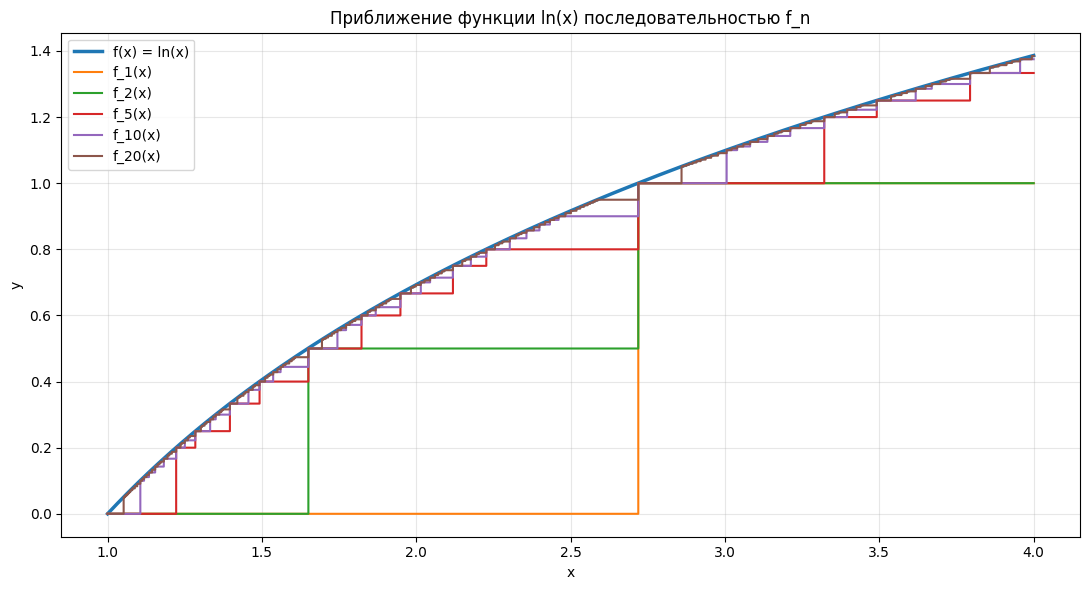

РЕЗУЛЬТАТЫ ЧИСЛЕННОГО МЕТОДА
2.2 Интеграл Лебега ∫ f_n dλ
-------------------------------------------------------------------------------------
n =   10 | ∫ f_n dλ ≈ 2.4764104029 | ошибка = 6.88e-02 | время = 0.0162 сек
n =  100 | ∫ f_n dλ ≈ 2.5440392396 | ошибка = 1.14e-03 | время = 0.1060 сек
n = 1000 | ∫ f_n dλ ≈ 2.5451618324 | ошибка = 1.56e-05 | время = 1.4240 сек

2.3 Интеграл Лебега–Стилтьеса ∫ f_n dμ_F
-------------------------------------------------------------------------------------
n =   10 | ∫ f_n dμ_F ≈ 14.8789682540 | ошибка = 4.57e-01 | время = 0.0002 сек
n =  100 | ∫ f_n dμ_F ≈ 15.3319684724 | ошибка = 3.96e-03 | время = 0.0002 сек
n = 1000 | ∫ f_n dμ_F ≈ 15.3358657620 | ошибка = 6.43e-05 | время = 0.0027 сек

Аналитические значения:
∫_[1, 4] ln(x) dλ     = 2.5451774445
∫_[1, 4] ln(x) dμ_F   = 15.3359300530

ВЫВОДЫ:
1. При увеличении n графики f_n ступенчато приближают ln(x) снизу.
2. Численные интегралы Лебега сходятся к аналитическому значению 4ln4−3.
3. Численные и

In [20]:
plot_functions()
compute_and_print_results()